# Runge Kutta 4th order method

Consider the following system of ordinary differential equations:

$
\begin{cases}
& x' = v \cos ( \theta) \\
& y' = v \sin ( \theta ) \\
& v' = a \\
& \theta' = \phi \\
\end{cases}
$

We can interpret this system as describing the motion of a particle in the plane, where 
- $x(t)$ and $y(t)$ represent the position of the particle at time $t$
- $v(t)$ is the speed of the particle
- $\theta(t)$ is the angle of the velocity vector with respect to the x-axis
- $a(t)$ is the acceleration
- $\phi(t)$ is the angular velocity.

With this, we can apply the classic Runge-Kutta 4th order method to approximate the solution of this system over a given time interval.

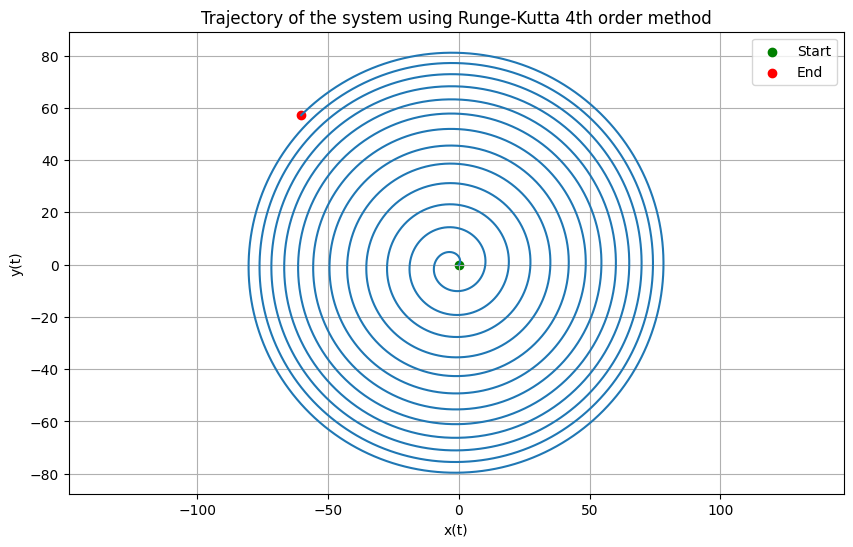

In [25]:
import numpy as np
import matplotlib.pyplot as plt

X0 = np.array([0, 0, 1, np.pi/4])
T = 100
N = 10000
dt = T / N
t = np.linspace(0, T, N+1)

def a(t):
    return np.exp(-0.01 * t)

def phi(t):
    return np.pi / 4

def f(X, t):
    x, y, v, theta = X
    dxdt = v * np.cos(theta)
    dydt = v * np.sin(theta)
    dvdt = a(t)
    dthetadt = phi(t)
    return np.array([dxdt, dydt, dvdt, dthetadt])

X = np.zeros((N+1, 4))
X[0] = X0
for i in range(N):
    k1 = f(X[i], t[i])
    k2 = f(X[i] + 0.5 * dt * k1, t[i] + 0.5 * dt)
    k3 = f(X[i] + 0.5 * dt * k2, t[i] + 0.5 * dt)
    k4 = f(X[i] + dt * k3, t[i] + dt)
    X[i+1] = X[i] + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

plt.figure(figsize=(10, 6))
plt.plot(X[:, 0], X[:, 1])
plt.scatter(X[0, 0], X[0, 1], color='green', label='Start')
plt.scatter(X[-1, 0], X[-1, 1], color='red', label='End')
plt.title('Trajectory of the system using Runge-Kutta 4th order method')
plt.xlabel('x(t)')
plt.ylabel('y(t)')
plt.grid()
plt.axis('equal')
plt.legend()
plt.show()